In [1]:
import os
import seaborn as sns
import plotly.express as px
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.io as pio
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches
from tabulate import tabulate

from hbn.constants import Defaults
from hbn.visualization import visualize as vis

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

In [129]:
## GET DATA

from hbn.data import make_dataset

# HARDCODE PARTICIPANTS + FEATURE_SPEC
participants = make_dataset.get_participants(
                            split='all', 
                            disorders=['ADHD-Combined_Type', 
                                        'ADHD-Inattentive_Type', 
                                        'ADHD-Hyperactive_Impulsive_Type', 
                                        'Other_Specified_Attention-Deficit_Hyperactivity_Disorder',
                                        'No_Diagnosis_Given']
                                        )

# get summary of clinical diagnosis + other demographics
df_all = make_dataset.make_summary(save=False)
df_all['Age'] = df_all['Age'].round()
#df_all = make_dataset._add_race_ethnicity(dataframe=df_all)
df_CGAS = make_dataset.add_CGAS_Score(df_all)

# get participants
df_part = pd.DataFrame(participants, columns=['Identifiers'])

# filter large dataframe to include only ADHD + No Diagnosis
df = df_all.merge(df_part, on='Identifiers')
df_CGAS = df_CGAS.merge(df_part, on='Identifiers')

In [130]:
## summary stats

sample_size = len(df_all['Identifiers'].unique())
print(f'total sample size of healthy brain network dataset is {sample_size}\n')

num_ADHD = len(df[df['DX_01_Cat_new']=='ADHD'])
num_no_diagnosis = len(df[df['DX_01_Cat_new']=='No Diagnosis Given'])
print(f'there are {num_ADHD} participants with ADHD and {num_no_diagnosis} with No Diagnosis\n')

# print out summaries
for diagnosis in ['ADHD', 'No Diagnosis Given']:
    print(f'PARTICIPANTS WITH {diagnosis}')
    
    tmp = df[df['DX_01_Cat_new']==diagnosis]
    
    sex = tmp['Sex'].value_counts()
    print(f'1. there are {sex.male} males and {sex.female} females\n')

    ages_6_10 = len(tmp[tmp['Age'].round()<=10])
    ages_10_21 = len(tmp[tmp['Age'].round()>10])
    print(f'2. there are {ages_6_10} children ages 6-10 and {ages_10_21} children ages 11-21\n')

    num_sites = len(tmp['Site'].unique())
    sites = tmp['Site'].value_counts()
    site_numbers = sites.index.tolist()
    site_count = sites.tolist()
    print(f'3. there are {num_sites} study sites and following # of participants collected across the following sites are {site_count}: {site_numbers}\n')

    years = tmp['Enroll_Year'].value_counts().index.astype(str).str.strip('.0').astype(int).tolist()
    num_years = len(tmp['Enroll_Year'].unique())
    print(f'4. data were collected across {num_years} years: {years}\n')

    num_subtypes = len(tmp['DX_01'].unique())
    subtypes = tmp['DX_01'].unique()
    print(f'5. there are {num_subtypes} unique subtypes: {subtypes}\n')

    comorbid = round((tmp['comorbidities'].value_counts() / len(tmp)) * 100)
    num_comorbid = comorbid[1:].sum()
    print(f'6. approximately {num_comorbid}% have disorder combordities\n')

    disorder_cat = round((tmp['DX_01'].value_counts() / len(tmp)) * 100).head(1)
    print(f'7. most prevalent subtype is {disorder_cat.index[0]} - {disorder_cat.values[0]}% of sample\n')

    disorder = round((tmp['DX_01_Cat_new'].value_counts() / len(tmp)) * 100).head(1)
    print(f'8. most prevalent category of diagnosis is {disorder.index[0]} - {disorder.values[0]}% of sample\n')

    tmp_CGAS = df_CGAS[df_CGAS['DX_01_Cat_new']==diagnosis]
    
    sex = tmp_CGAS.groupby(['Sex']).agg({'CGAS_Score': 'mean'})
    f_cgas = sex.loc['male'].values[0]
    m_cgas = sex.loc['female'].values[0]
    print(f'9. females have an average general functioning score (CGAS) of {round(f_cgas)}% and males {round(m_cgas)}%\n')



total sample size of healthy brain network dataset is 4767

there are 1905 participants with ADHD and 373 with No Diagnosis

PARTICIPANTS WITH ADHD
1. there are 1370 males and 535 females

2. there are 1235 children ages 6-10 and 670 children ages 11-21

3. there are 5 study sites and following # of participants collected across the following sites are [842, 537, 471, 42, 13]: [1, 4, 3, 5, 2]

4. data were collected across 8 years: [2018, 2019, 2017, 202, 2016, 2021, 2015, 2022]

5. there are 4 unique subtypes: ['ADHD-Combined Type' 'ADHD-Inattentive Type'
 'Other Specified Attention-Deficit/Hyperactivity Disorder'
 'ADHD-Hyperactive/Impulsive Type']

6. approximately 69.0% have disorder combordities

7. most prevalent subtype is ADHD-Combined Type - 45.0% of sample

8. most prevalent category of diagnosis is ADHD - 100.0% of sample

9. females have an average general functioning score (CGAS) of 64% and males 65%

PARTICIPANTS WITH No Diagnosis Given
1. there are 198 males and 175 fema

## Descriptive Statistics

<Figure size 1280x880 with 0 Axes>

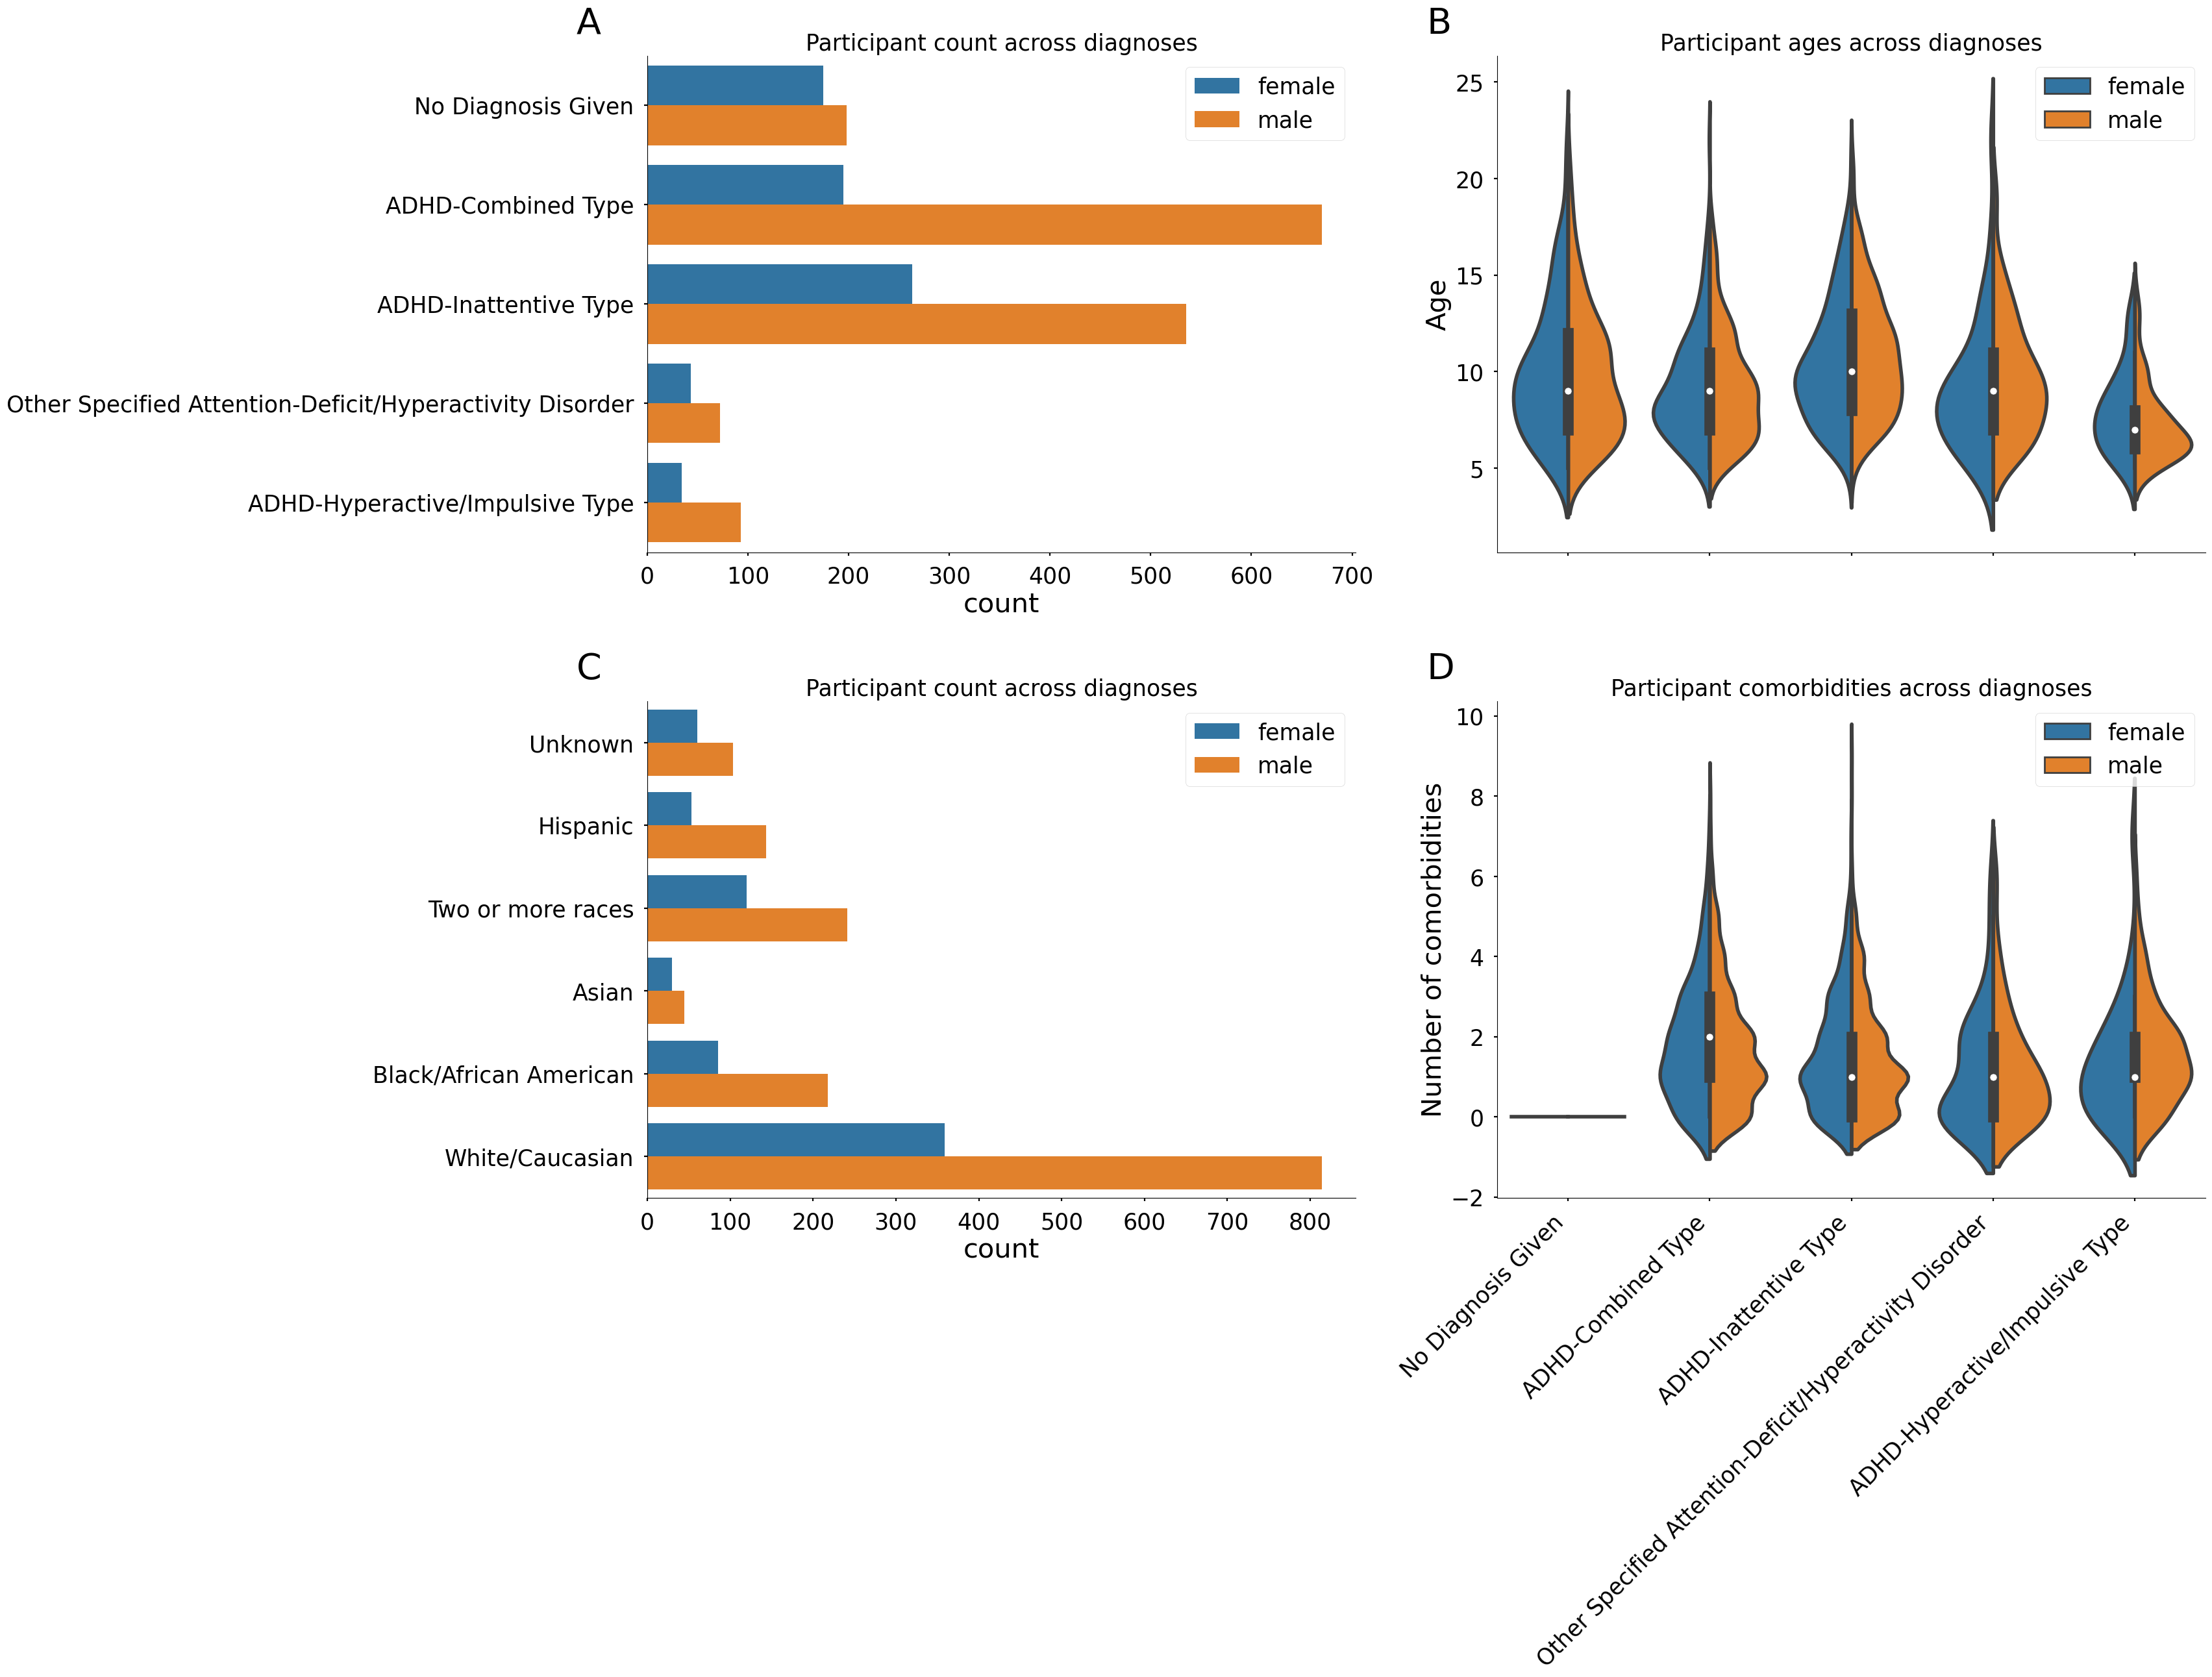

In [131]:
plt.clf()
vis.plotting_style()
x_pos = -0.1
y_pos = 1.1
labelsize = 40

fig = plt.figure()
gs = GridSpec(2, 2, figure=fig)

ax = fig.add_subplot(gs[0,0])
ax = sns.countplot(data=df, y='DX_01', hue='Sex', ax=ax)
ax.set_ylabel('')
ax.set_title('Participant count across diagnoses')
ax.text(x_pos, y_pos, 'A', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')
ax.legend_.set_title(None)

ax = fig.add_subplot(gs[0,1])
ax = sns.violinplot(x='DX_01', y='Age', hue='Sex', split=True, data=df, ax=ax)
plt.xticks(rotation=45, ha='right');
ax.set_xticklabels('')
ax.set_xlabel('')
ax.set_title('Participant ages across diagnoses')
ax.text(x_pos, y_pos, 'B', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')
ax.legend_.set_title(None)

ax = fig.add_subplot(gs[1,0])
tmp = df[df['PreInt_Demos_Fam,Child_Race_cat'].isin(['Unknown', 'Hispanic', 'Two or more races', 'Asian',
       'Black/African American', 'White/Caucasian'])]
ax = sns.countplot(data=tmp, y='PreInt_Demos_Fam,Child_Race_cat', hue='Sex', ax=ax)
ax.set_ylabel('')
ax.set_title('Participant count across diagnoses')
ax.text(x_pos, y_pos, 'C', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')
ax.legend_.set_title(None)


ax = fig.add_subplot(gs[1,1])
ax = sns.violinplot(x='DX_01', y='comorbidities', hue='Sex', split=True, data=df, ax=ax)
plt.xticks(rotation=45, ha='right');
ax.set_ylabel('Number of comorbidities')
ax.set_xlabel('')
ax.set_title('Participant comorbidities across diagnoses')
ax.text(x_pos, y_pos, 'D', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')
ax.legend_.set_title(None)

plt.subplots_adjust(left=0.125, bottom=0.001, right=2.0, top=2.0, wspace=.2, hspace=.3)

#save_path = os.path.join(dirs.figure, f'fig1.svg')
#plt.savefig(save_path, bbox_inches="tight", dpi=300)

## Participant Count

In [132]:
tmp = df.groupby(
    ['DX_01', 'Sex']).count()[['Identifiers']].reset_index().rename(
    {'Identifiers': 'Participant Count'}, axis=1)

head = ['Diagnosis', 'Sex', '# of Participants']
print(tabulate(np.array(tmp), headers=head, tablefmt="grid"))


+----------------------------------------------------------+--------+---------------------+
| Diagnosis                                                | Sex    |   # of Participants |
+==========================================================+========+=====================+
| ADHD-Combined Type                                       | female |                 195 |
+----------------------------------------------------------+--------+---------------------+
| ADHD-Combined Type                                       | male   |                 670 |
+----------------------------------------------------------+--------+---------------------+
| ADHD-Hyperactive/Impulsive Type                          | female |                  34 |
+----------------------------------------------------------+--------+---------------------+
| ADHD-Hyperactive/Impulsive Type                          | male   |                  93 |
+----------------------------------------------------------+--------+-----------

## Age

In [133]:
tmp = df.groupby(
    ['DX_01', 'Sex'])['Age'].agg(
    {'mean', 'std'}).reset_index().rename(
    {'mean': 'mean (age)', 'std': 'std (age)'}, axis=1)

head = tmp.columns.tolist()
print(tabulate(np.array(tmp), headers=head, tablefmt="grid"))


+----------------------------------------------------------+--------+--------------+-------------+
| DX_01                                                    | Sex    |   mean (age) |   std (age) |
+==========================================================+========+==============+=============+
| ADHD-Combined Type                                       | female |      9.22051 |     2.857   |
+----------------------------------------------------------+--------+--------------+-------------+
| ADHD-Combined Type                                       | male   |      9.24627 |     2.88814 |
+----------------------------------------------------------+--------+--------------+-------------+
| ADHD-Hyperactive/Impulsive Type                          | female |      7.94118 |     2.14534 |
+----------------------------------------------------------+--------+--------------+-------------+
| ADHD-Hyperactive/Impulsive Type                          | male   |      7.33333 |     2.01264 |
+---------

## Race/Ethnicity

In [134]:
tmp = df[df['PreInt_Demos_Fam,Child_Race_cat'].isin(['Unknown', 'Hispanic', 'Two or more races', 'Asian',
       'Black/African American', 'White/Caucasian'])]


tmp = df.groupby(
    ['PreInt_Demos_Fam,Child_Race_cat', 'Sex']).count()[['Identifiers']].reset_index().rename(
    {'Identifiers': 'Participant Count'}, axis=1)

head = ['Race/Ethnicity', 'Sex', '# of Participants']
print(tabulate(np.array(tmp), headers=head, tablefmt="grid"))


+----------------------------------------+--------+---------------------+
| Race/Ethnicity                         | Sex    |   # of Participants |
+========================================+========+=====================+
| Asian                                  | female |                  30 |
+----------------------------------------+--------+---------------------+
| Asian                                  | male   |                  45 |
+----------------------------------------+--------+---------------------+
| Black/African American                 | female |                  85 |
+----------------------------------------+--------+---------------------+
| Black/African American                 | male   |                 218 |
+----------------------------------------+--------+---------------------+
| Hispanic                               | female |                  53 |
+----------------------------------------+--------+---------------------+
| Hispanic                            

## Comorbidities

In [135]:
tmp = df.groupby(
    ['DX_01', 'Sex'])['comorbidities'].agg(
    {'mean', 'std'}).reset_index().rename(
    {'mean': 'mean (comorbidities)', 'std': 'std (comorbidities)'}, axis=1)

head = tmp.columns.tolist()
print(tabulate(np.array(tmp), headers=head, tablefmt="grid"))

+----------------------------------------------------------+--------+------------------------+-----------------------+
| DX_01                                                    | Sex    |   mean (comorbidities) |   std (comorbidities) |
+==========================================================+========+========================+=======================+
| ADHD-Combined Type                                       | female |                1.84615 |               1.49808 |
+----------------------------------------------------------+--------+------------------------+-----------------------+
| ADHD-Combined Type                                       | male   |                1.79104 |               1.54492 |
+----------------------------------------------------------+--------+------------------------+-----------------------+
| ADHD-Hyperactive/Impulsive Type                          | female |                1.32353 |               1.47135 |
+-----------------------------------------------

## CGAS Score (General Cognitive Functioning)

<Figure size 1280x880 with 0 Axes>

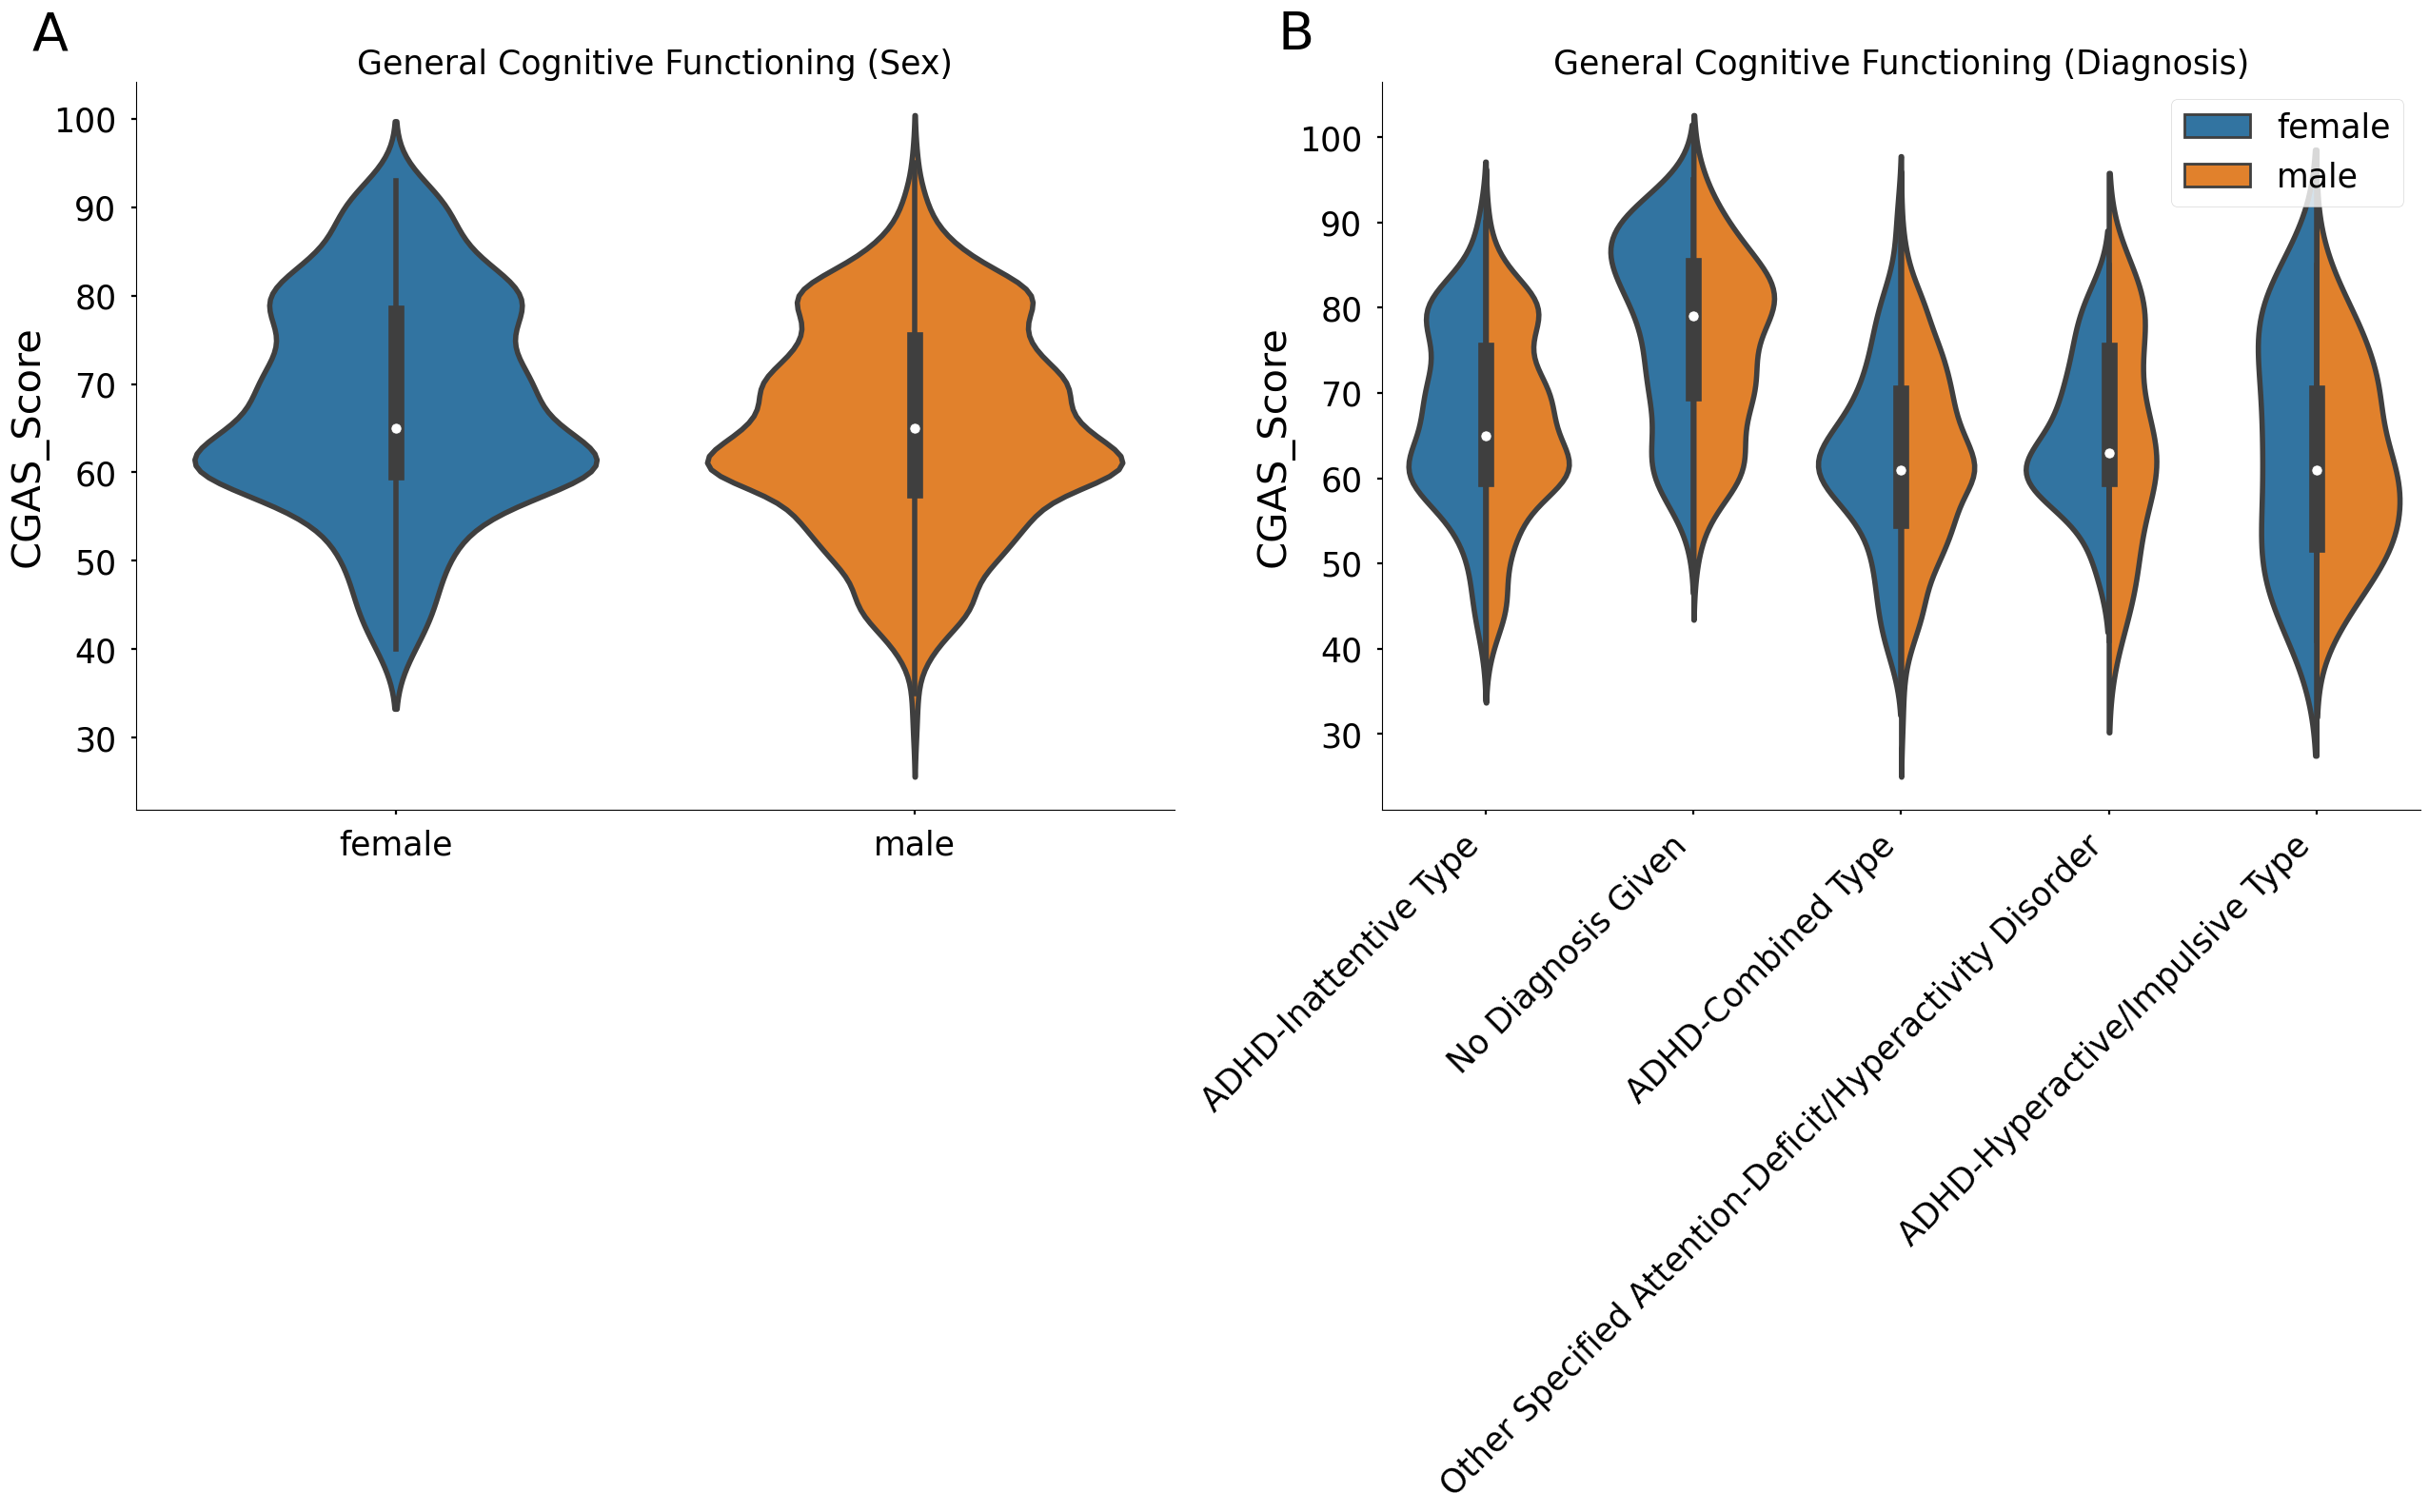

In [136]:
plt.clf()
vis.plotting_style()
x_pos = -0.1
y_pos = 1.1
labelsize = 40

fig = plt.figure()
gs = GridSpec(2, 2, figure=fig)

ax = fig.add_subplot(gs[0,0])
ax = sns.violinplot(data=df_CGAS, x='Sex', y='CGAS_Score', ax=ax)
ax.set_xlabel('')
ax.set_title('General Cognitive Functioning (Sex)')
ax.text(x_pos, y_pos, 'A', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')

ax = fig.add_subplot(gs[0,1])
ax = sns.violinplot(data=df_CGAS, x='DX_01', y='CGAS_Score', hue='Sex', split=True, ax=ax)
plt.xticks(rotation=45, ha='right');
ax.set_xlabel('')
ax.set_title('General Cognitive Functioning (Diagnosis)')
ax.text(x_pos, y_pos, 'B', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')
ax.legend_.set_title(None)

plt.subplots_adjust(left=0.125, bottom=0.001, right=2.0, top=2.0, wspace=.2, hspace=.3)


In [137]:
tmp = df_CGAS.groupby(
    ['DX_01', 'Sex'])['CGAS_Score'].agg(
    {'mean', 'std'}).reset_index().rename(
    {'mean': 'mean (CGAS)', 'std': 'std (CGAS)'}, axis=1)

head = tmp.columns.tolist()
print(tabulate(np.array(tmp), headers=head, tablefmt="grid"))

+----------------------------------------------------------+--------+---------------+--------------+
| DX_01                                                    | Sex    |   mean (CGAS) |   std (CGAS) |
+==========================================================+========+===============+==============+
| ADHD-Combined Type                                       | female |       62.3455 |     10.7984  |
+----------------------------------------------------------+--------+---------------+--------------+
| ADHD-Combined Type                                       | male   |       62.2609 |     10.7143  |
+----------------------------------------------------------+--------+---------------+--------------+
| ADHD-Hyperactive/Impulsive Type                          | female |       63.8667 |     13.3745  |
+----------------------------------------------------------+--------+---------------+--------------+
| ADHD-Hyperactive/Impulsive Type                          | male   |       61.8875 |     1

## Year of Enrollment

<Figure size 1280x880 with 0 Axes>

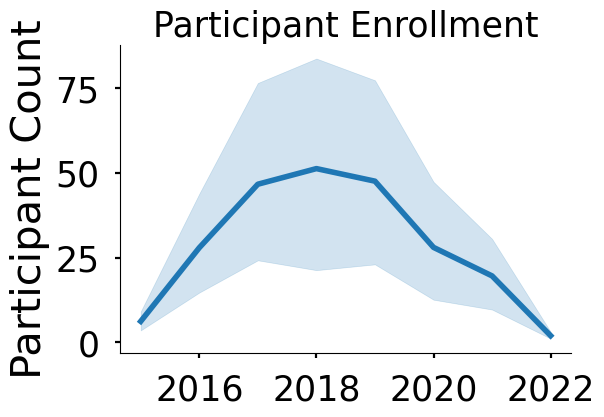

In [142]:
plt.clf()
vis.plotting_style()
x_pos = -0.1
y_pos = 1.1
labelsize = 40

fig = plt.figure()
gs = GridSpec(2, 2, figure=fig)

tmp = df.groupby(
    ['Enroll_Year', 'DX_01', 'Sex']).count()[['Identifiers']].reset_index().rename(
    {'Identifiers': 'Participant Count'}, axis=1)

ax = fig.add_subplot(gs[0,0])
ax = sns.lineplot(data=tmp, x='Enroll_Year', y='Participant Count', ax=ax)
ax.set_xlabel('')
ax.set_title('Participant Enrollment');

In [139]:
tmp = df.groupby(
    ['Enroll_Year', 'DX_01', 'Sex']).count()[['Identifiers']].reset_index().rename(
    {'Identifiers': 'Participant Count'}, axis=1)

head = ['Enrollment Year', 'Diagnosis', 'Sex', '# of Participants']
print(tabulate(np.array(tmp), headers=head, tablefmt="grid"))


+-------------------+----------------------------------------------------------+--------+---------------------+
|   Enrollment Year | Diagnosis                                                | Sex    |   # of Participants |
+===================+==========================================================+========+=====================+
|              2015 | ADHD-Combined Type                                       | female |                   4 |
+-------------------+----------------------------------------------------------+--------+---------------------+
|              2015 | ADHD-Combined Type                                       | male   |                  15 |
+-------------------+----------------------------------------------------------+--------+---------------------+
|              2015 | ADHD-Hyperactive/Impulsive Type                          | male   |                   1 |
+-------------------+----------------------------------------------------------+--------+---------------

## 

## Results from Predictive Models

In this section, we're building models on different sets of features (Child, Parent, Teacher Measures and basic demographics (e.g., race, ethnicity, age, sex) and determining how well these models classify whether or not someone has a diagnosis (versus no diagnosis). 

We are building models separately for males and females to identify whether certain features (or all features) classify males better than females (or vice versa)

We have built models on the following diagnoses: ADHD, ASD, Depression, Anxiety, Reading Impairment (our primary interest is ADHD but we can interpret results for ADHD model relative to the other diagnoses)

In [61]:

models_dict = { 'ADHD-incl-comorbidities': 'all_feature_models/2023-03-16_15-03-36-30', # incl comobordities
                'ADHD': 'all_feature_models/2023-03-17_16-20-51-94',
                'ADHD-females': 'all_feature_models/2023-03-19_15-30-41-41S-99',
                'ADHD-males': 'all_feature_models/2023-03-19_15-30-25-25S-53',
               'ADHD-fullmodel': 'all_feature_models/2023-04-01_18-18-41-72',
               'ADHD-fullmodel-males': 'all_feature_models/2023-04-05_17-24-04-04S-8',
               'ADHD-fullmodel-females': 'all_feature_models/2023-04-06_11-33-22-22S-60',
               'ASD': 'all_feature_models/2023-03-21_17-42-28-28S-61',
               'ASD-females': 'all_feature_models/2023-03-19_15-31-26-26S-7',
               'ASD-males': 'all_feature_models/2023-03-22_16-13-13-13S-76',
               'ASD-fullmodel': 'all_feature_models/2023-04-03_10-31-05-05S-20',
               'ASD-fullmodel-females': 'all_feature_models/2023-04-05_08-38-54-54S-26',
               'ASD-fullmodel-males': 'all_feature_models/2023-04-05_08-38-53-53S-82',
               'Depression': 'all_feature_models/2023-03-19_15-30-01-01S-5', 
               'Depression-females': 'all_feature_models/2023-03-22_17-43-23-23S-41',
               'Depression-males': 'all_feature_models/2023-03-22_17-43-23-23S-13',
               'Depression-fullmodel': 'all_feature_models/2023-04-05_08-38-55-55S-54',
               'Depression-fullmodel-females': 'all_feature_models/2023-04-05_08-38-54-54S-42',
               'Depression-fullmodel-males': 'all_feature_models/2023-04-06_11-33-19-19S-98',
               'Anxiety-females': 'all_feature_models/2023-03-22_17-43-19-19S-66',
               'Anxiety-males': 'all_feature_models/2023-03-22_17-43-14-14S-30',
               'Anxiety-fullmodel': 'all_feature_models/2023-04-05_17-22-04-04S-21',
               'Anxiety-fullmodel-males':'all_feature_models/2023-04-05_17-26-05-05S-96',
               'Anxiety-fullmodel-females': 'all_feature_models/2023-04-06_11-33-21-21S-57',
               'Reading Impairment': 'all_feature_models/2023-03-19_15-45-21-21S-72',
               'Reading Impairment-females': 'all_feature_models/2023-03-22_17-43-10-10S-35',
               'Reading Impairment-males': 'all_feature_models/2023-03-19_15-31-26-26S-7',
               'Reading Impairment-fullmodel': 'all_feature_models/2023-04-05_17-24-04-04S-97',
               'Reading Impairment-fullmodel-females': 'all_feature_models/2023-04-05_17-24-04-04S-11',
               'Reading Impairment-fullmodel-males': 'all_feature_models/2023-04-05_17-24-04-04S-31',
              }

# loop over models
df_all = pd.DataFrame()
for key, value in models_dict.items():
    MODEL_DIR = os.path.join(Defaults.MODEL_DIR, value)

    df_classify = pd.read_csv(os.path.join(MODEL_DIR, 'classifier-all-phenotypic-models-performance.csv'))
    df_classify['data'] = df_classify['data'].map({'model-data': 'null', 'model-null': 'data'})
    df_classify['participant_group'] = key
    
    df_all = pd.concat([df_all, df_classify])
    
# do some remapping
df_all['features'] = df_all['features'].map({'Child Measures-all': 'Child Measures',
                    'Parent Measures-all': 'Parent Measures',
                    'Teacher Measures-all': 'Teacher Measures',
                    'Parent Measures-Basic_Demos': 'Demographics'}
                   )

## Predictive Modeling - ADHD for Child, Parent, Teacher, Demographics

A result of 50% is chance level (model is not distinguishing between either group) -- chance is indicated in the figures with a dashed black line. 100% is a perfect classification. 

Interpreting the figure:
* A) Parent and Child measures are well above chance (80, 85% respectively) while demographics and Teacher measures are close to chance. In distinguishing whether participants have ADHD or no diagnosis, the parent model does best, followed closely by the child model.
* B) When we split by sex, we can see that for each model, the males are better classified than females

ValueError: There must be exactly two hue levels to use `split`.'

<Figure size 1280x880 with 0 Axes>

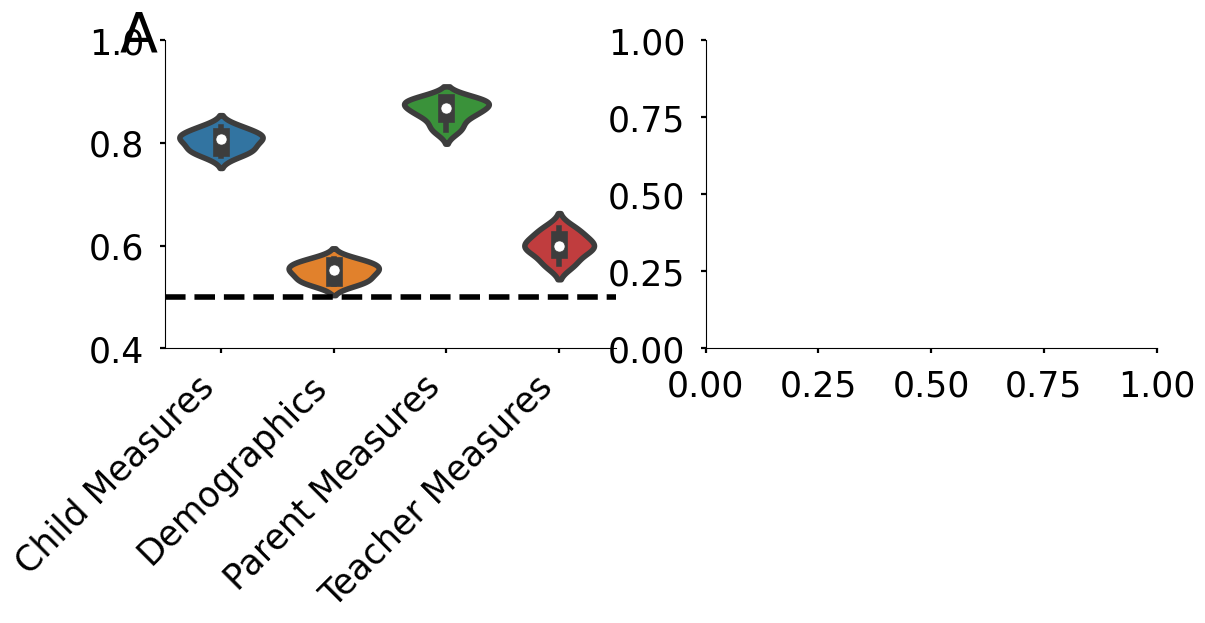

In [63]:
plt.clf()
vis.plotting_style()
x_pos = -0.1
y_pos = 1.1
labelsize = 40

fig = plt.figure()
gs = GridSpec(2, 2, figure=fig)

ax = fig.add_subplot(gs[0,0])
df1 = df_all[
    (df_all['participant_group']=='ADHD') & 
    (df_all['target']=='DX_01_Cat_new_binarize') &
    (df_all['data']=='data')
    ]
ax = sns.violinplot(x='features', y='roc_auc_score', data=df1, ax=ax)
plt.xticks(rotation=45, ha='right')
ax.set_xlabel('')
ax.set_ylabel('')
#ax.set_title('')
plt.axhline(y=0.5, color='k', linestyle='--')
ax.text(x_pos, y_pos, 'A', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')
ax.set_ylim([0.4, 1])

ax = fig.add_subplot(gs[0,1])
df1 = df_all[
    (df_all['participant_group'].str.contains('ADHD-')) & 
    (df_all['target']=='DX_01_Cat_new_binarize') &
    (df_all['data']=='data') 
    ]
ax = sns.violinplot(x='features', y='roc_auc_score', hue='participant_group', split=True, data=df1, ax=ax)
plt.xticks(rotation=45, ha='right')
ax.set_xlabel('')
ax.set_ylabel('')
#ax.set_title('')
plt.axhline(y=0.5, color='k', linestyle='--')
ax.text(x_pos, y_pos, 'B', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')
ax.legend_.set_title(None)
ax.set_ylim([0.4, 1])

plt.subplots_adjust(left=0.125, bottom=0.001, right=2.0, top=2.0, wspace=.2, hspace=.3)

## Predictive Modeling - Depression, ASD, Anxiety, Reading Impairment for Child, Parent, Teacher, Demographics

Interpreting the figure:
* A) Models classify depression quite well (around 80%) - demographics and teacher slightly lower. Females are better classified than males for both demographics and teacher measures
* B) similar pattern of results for anxiety as depression except that scores are sig. lower
* C) demographic and teacher models are close to chance for reading impairment (and no sig. male/female differences). For parent and child measures, the classifier predicts pretty well (about 80%) and there is a dissociation between males and females across these measures. Males are far better classified than females by the parent model and vice versa for the child model. 
* D) For the ASD group, there are no classification differences between males and females, parent model sig. outperforms child, teacher, demographics at 90% accuracy


* *ADHD is the only diagnosis where males are consistently better classified than females across all assessments*

ValueError: There must be exactly two hue levels to use `split`.'

<Figure size 1280x880 with 0 Axes>

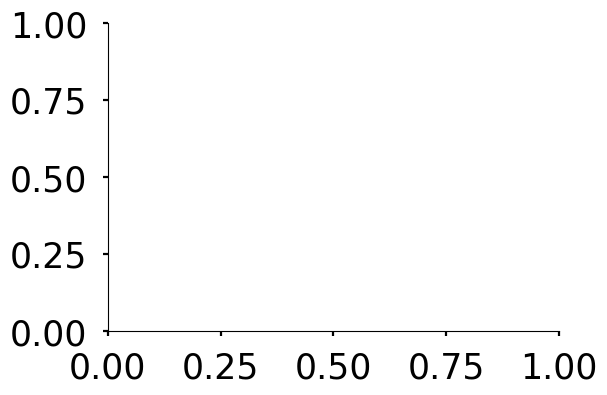

In [64]:
plt.clf()
vis.plotting_style()
x_pos = -0.1
y_pos = 1.1
labelsize = 40

fig = plt.figure()
gs = GridSpec(2, 2, figure=fig)

# A
ax = fig.add_subplot(gs[0,0])
df1 = df_all[
    (df_all['participant_group'].str.contains('Depression-')) & 
    (df_all['target']=='DX_01_Cat_new_binarize') &
    (df_all['data']=='data') 
    ]
ax = sns.violinplot(x='features', y='roc_auc_score', hue='participant_group', split=True, data=df1, ax=ax)
plt.xticks(rotation=45, ha='right')
ax.set_xlabel('')
plt.xticks([]) 
ax.set_ylabel('')
ax.set_title('Depression', fontsize=45)
plt.axhline(y=0.5, color='k', linestyle='--')
#ax.text(x_pos, y_pos, 'A', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')
ax.set_ylim([0.3, 1])
ax.legend_.set_title(None)
ax.legend().set_visible(False)

# B
ax = fig.add_subplot(gs[0,1])
df1 = df_all[
    (df_all['participant_group'].str.contains('Anxiety-')) & 
    (df_all['target']=='DX_01_Cat_new_binarize') &
    (df_all['data']=='data') 
    ]
ax = sns.violinplot(x='features', y='roc_auc_score', hue='participant_group', split=True, data=df1, ax=ax)
plt.xticks(rotation=45, ha='right')
ax.set_xlabel('')
plt.xticks([]) 
ax.set_ylabel('')
ax.set_title('Anxiety', fontsize=45)
plt.axhline(y=0.5, color='k', linestyle='--')
#ax.text(x_pos, y_pos, 'B', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')
ax.legend_.set_title(None)
ax.set_ylim([0.3, 1])
ax.legend().set_visible(False)

# C
ax = fig.add_subplot(gs[1,0])
df1 = df_all[
    (df_all['participant_group'].str.contains('Reading Impairment-')) & 
    (df_all['target']=='DX_01_Cat_new_binarize') &
    (df_all['data']=='data') 
    ]
ax = sns.violinplot(x='features', y='roc_auc_score', hue='participant_group', split=True, data=df1, ax=ax)
plt.xticks(rotation=45, ha='right')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Reading Impairment', fontsize=45)
plt.axhline(y=0.5, color='k', linestyle='--')
#ax.text(x_pos, y_pos, 'B', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')
ax.legend_.set_title(None)
ax.set_ylim([0.3, 1])
ax.legend().set_visible(False)

# D
ax = fig.add_subplot(gs[1,1])
df1 = df_all[
    (df_all['participant_group'].str.contains('ASD-')) & 
    (df_all['target']=='DX_01_Cat_new_binarize') &
    (df_all['data']=='data') 
    ]
ax = sns.violinplot(x='features', y='roc_auc_score', hue='participant_group', split=True, data=df1, ax=ax)
plt.xticks(rotation=45, ha='right')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Autism Spectrum Disorder',  fontsize=45)
plt.axhline(y=0.5, color='k', linestyle='--')
#ax.text(x_pos, y_pos, 'B', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')
ax.legend_.set_title(None)
plt.legend(loc='upper left')
ax.set_ylim([0.3, 1])
ax.legend().set_visible(False)

plt.subplots_adjust(left=0.125, bottom=0.002, right=2.0, top=2.5, wspace=.2, hspace=.3)


In [ ]:
plt.clf()
vis.plotting_style()
x_pos = -0.1
y_pos = 1.1
labelsize = 40

fig = plt.figure()
gs = GridSpec(2, 1, figure=fig)

# A
ax = fig.add_subplot(gs[0,0])
df1 = df_all[
    (df_all['participant_group'].str.contains('-fullmodel-males|-fullmodel-females')) & 
    (df_all['target']=='DX_01_Cat_new_binarize') &
    (df_all['data']=='data') 
    ]
df1['diagnosis'] = df1['participant_group'].str.split('-').str.get(0)
df1['sex'] = df1['participant_group'].str.split('-').str.get(2)

ax = sns.violinplot(x='diagnosis', y='roc_auc_score', hue='sex', split=True, data=df1, ax=ax)
plt.xticks(rotation=45, ha='right')
#ax.set_xlabel('')
#plt.xticks([]) 
ax.set_ylabel('ROC AUC')
#ax.set_title('Depression', fontsize=45)
plt.axhline(y=0.5, color='k', linestyle='--')
#ax.text(x_pos, y_pos, 'A', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')
ax.set_ylim([0.4, 1])
ax.legend_.set_title(None)
ax.legend().set_visible(False)

plt.subplots_adjust(left=0.125, bottom=0.002, right=2.0, top=2.5, wspace=.2, hspace=.3)


## Interpreting Model Features - UNDER CONSTRUCTION

In [ ]:

models_dict = {
                'ADHD': 'all_feature_models/2023-03-17_16-20-51-94',
                'ASD-females': 'all_feature_models/2023-03-19_15-31-26-26S-7',
                'ASD-males': 'all_feature_models/2023-03-22_16-13-13-13S-76',
                'ADHD-females': 'all_feature_models/2023-03-19_15-30-41-41S-99',
                'ADHD-males': 'all_feature_models/2023-03-19_15-30-25-25S-53',
               'Depression-females': 'all_feature_models/2023-03-22_17-43-23-23S-41',
               'Depression-males': 'all_feature_models/2023-03-22_17-43-23-23S-13',
               'Anxiety-females': 'all_feature_models/2023-03-22_17-43-19-19S-66',
               'Anxiety-males': 'all_feature_models/2023-03-22_17-43-14-14S-30',
               'Reading Impairment-females': 'all_feature_models/2023-03-22_17-43-10-10S-35',
               'Reading Impairment-males': 'all_feature_models/2023-03-19_15-31-26-26S-7' 
              }

# loop over models
df_all = pd.DataFrame()
for key, value in models_dict.items():
    MODEL_DIR = os.path.join(Defaults.MODEL_DIR, value)
    
    try:
        df_feat = pd.read_csv(os.path.join(MODEL_DIR, 'classifier-feature_importance.csv'))
        df_feat['participant_group'] = key
    
        # do some remapping
        df_feat['features'] = df_feat['features'].map({'Child Measures-all': 'Child Measures',
                    'Parent Measures-all': 'Parent Measures',
                    'Teacher Measures-all': 'Teacher Measures',
                    'Parent Measures-Basic_Demos': 'Demographics'}
                   )
        df_all = pd.concat([df_all, df_feat])
    except:
        pass